# 01 - KNN Pokemon Classifier (Name as target)

Objetivo del notebook:
- entrenar un modelo KNN para predecir `Name` a partir de atributos del Pokemon,
- encapsular preprocesamiento + modelo en un `Pipeline`,
- exportar el artefacto entrenado para usarlo en Streamlit/produccion.


## 1. Imports and setup

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Pokemon.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

%matplotlib inline

DATA_PATH


PosixPath('/workspaces/ml_for_production_talk/ml-production-app/data/raw/Pokemon.csv')

## 2. Load and inspect data

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[df["Generation"] == 1].copy()

print("Filtered to Generation 1 only")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Filtered to Generation 1 only
Shape: (166, 13)
Columns: ['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Type 2    88
dtype: int64

## 3. Quick exploratory analysis

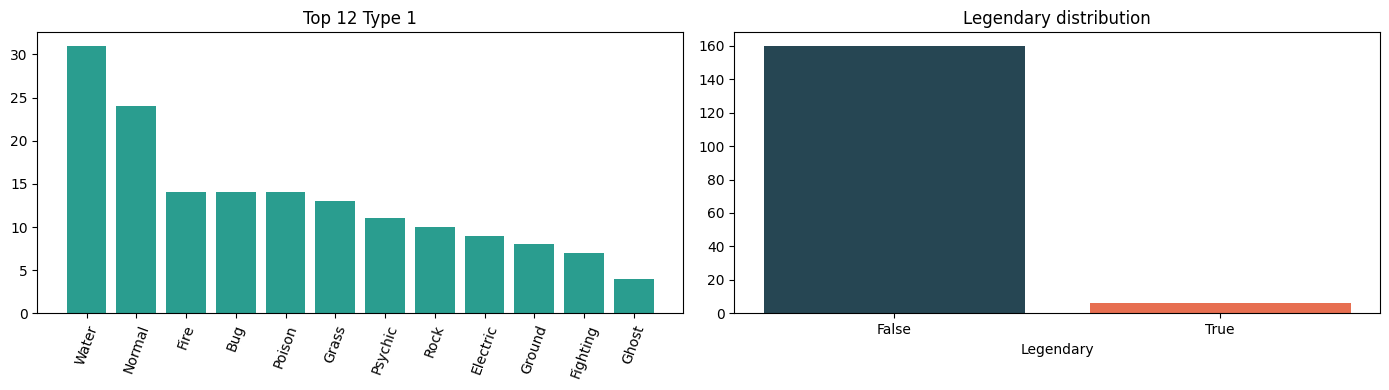

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_counts = df["Type 1"].value_counts().head(12)
axes[0].bar(type_counts.index, type_counts.values, color="#2a9d8f")
axes[0].set_title("Top 12 Type 1")
axes[0].tick_params(axis="x", rotation=70)

legendary_counts = df["Legendary"].value_counts()
axes[1].bar(legendary_counts.index.astype(str), legendary_counts.values, color=["#264653", "#e76f51"])
axes[1].set_title("Legendary distribution")
axes[1].set_xlabel("Legendary")

plt.tight_layout()
plt.show()

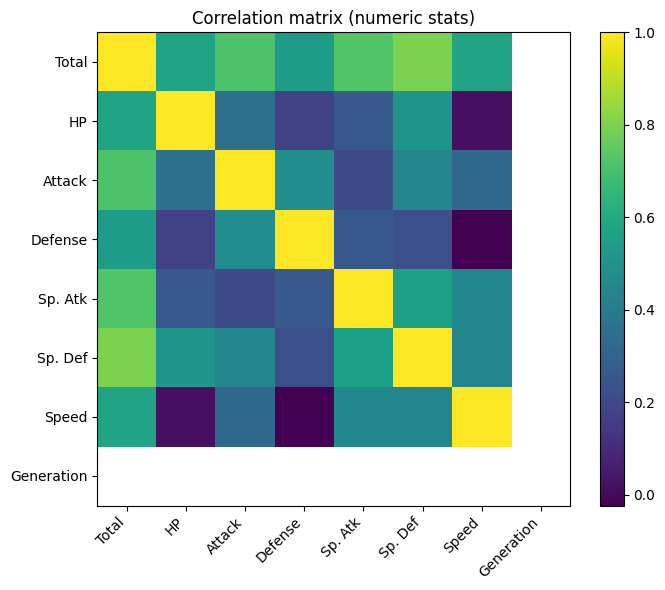

In [5]:
numeric_cols = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation"]

corr = df[numeric_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="viridis")
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
ax.set_title("Correlation matrix (numeric stats)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 3.1 More visual exploration


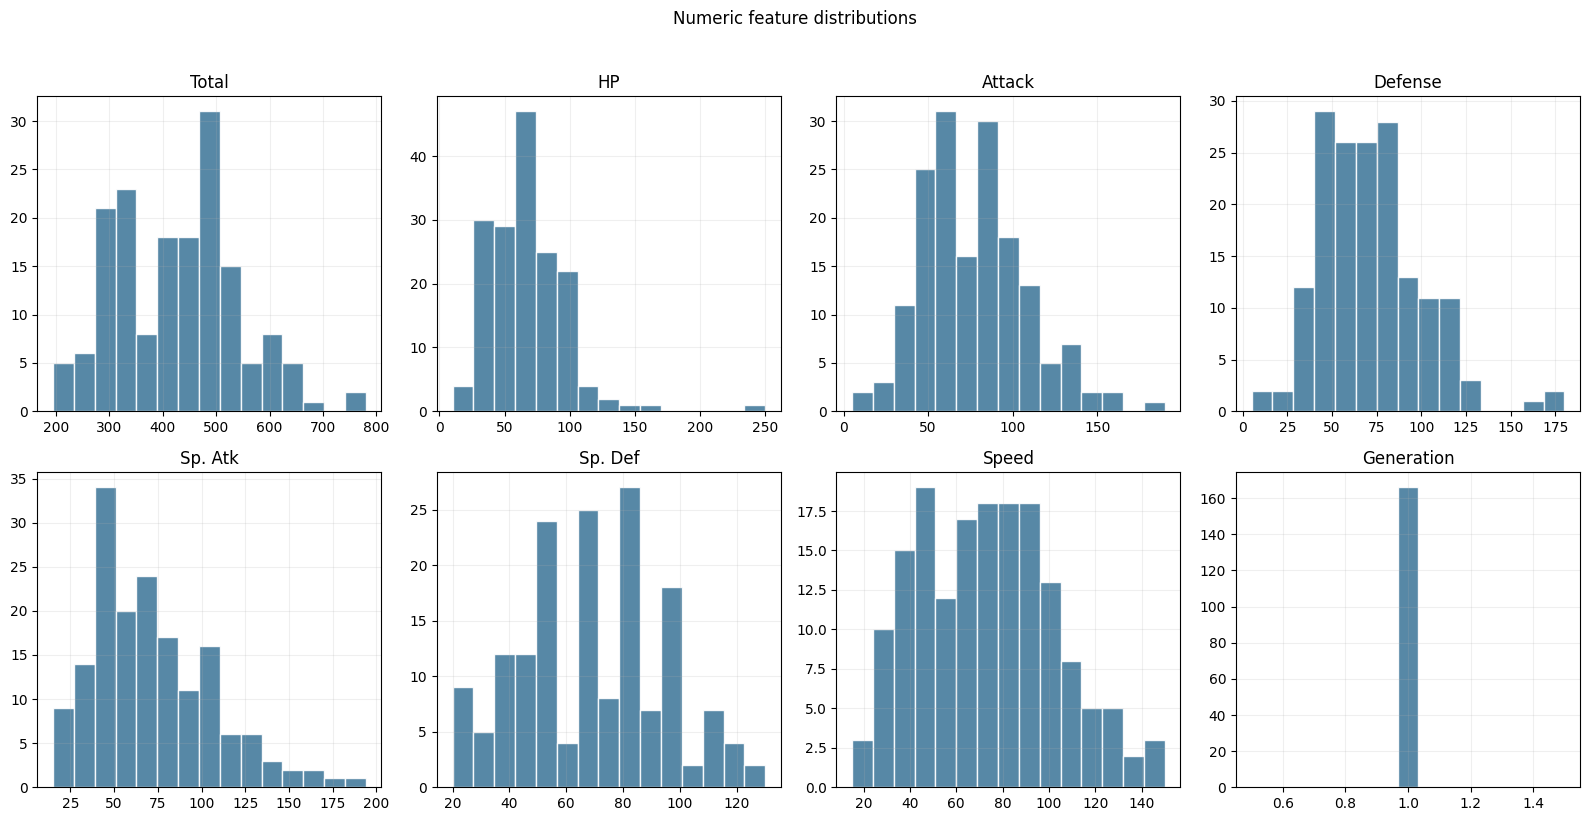

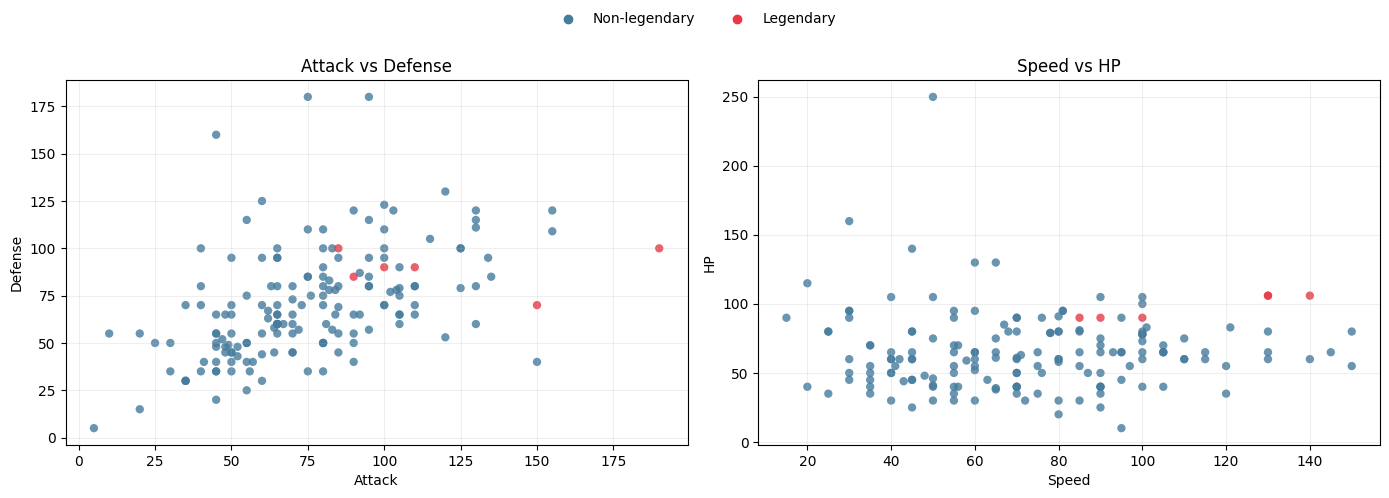

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(df[col].dropna(), bins=15, color="#457b9d", edgecolor="white", alpha=0.9)
    ax.set_title(col)
    ax.grid(alpha=0.2)

plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout()
plt.show()

legendary_color = df["Legendary"].astype(str).map({"False": "#457b9d", "True": "#e63946"}).fillna("#457b9d")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df["Attack"], df["Defense"], c=legendary_color, alpha=0.8, edgecolors="none")
axes[0].set_title("Attack vs Defense")
axes[0].set_xlabel("Attack")
axes[0].set_ylabel("Defense")
axes[0].grid(alpha=0.2)

axes[1].scatter(df["Speed"], df["HP"], c=legendary_color, alpha=0.8, edgecolors="none")
axes[1].set_title("Speed vs HP")
axes[1].set_xlabel("Speed")
axes[1].set_ylabel("HP")
axes[1].grid(alpha=0.2)

legend_handles = [
    plt.Line2D([], [], marker="o", linestyle="", color="#457b9d", label="Non-legendary"),
    plt.Line2D([], [], marker="o", linestyle="", color="#e63946", label="Legendary"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## 4. Define target, features, and training split

In [7]:
target_col = "Name"
feature_cols = [
    "Type 1", "Type 2", "Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation", "Legendary",
]

X = df[feature_cols].copy()
y = df[target_col].astype(str)

# Robustez para versiones recientes: normalizamos categoricas antes del pipeline
for col in ["Type 1", "Type 2", "Legendary"]:
    X[col] = X[col].fillna("Unknown").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Unique pokemon in target:", y.nunique())

Train shape: (132, 11)
Test shape: (34, 11)
Unique pokemon in target: 166


## 5. Build preprocessing + KNN pipeline

In [8]:
numeric_features = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Generation"]
categorical_features = ["Type 1", "Type 2", "Legendary"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=3, weights="distance")),
    ]
)

knn_pipeline.fit(X_train, y_train)
knn_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Total', 'HP', 'Attack',
                                                   'Defense', 'Sp. Atk',
                                                   'Sp. Def', 'Speed',
                                                   'Generation']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Type 1', 'Type 2',
                                                   'Legendary'])])),
                ('model',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])

## 6. Basic evaluation (demo-oriented)

Nota: este dataset tiene muchisimas clases (nombres unicos), por lo que la metrica no sera alta. Para la charla nos importa tener un flujo funcional de entrenamiento + serving.


In [9]:
y_pred = knn_pipeline.predict(X_test)
top1_acc = accuracy_score(y_test, y_pred)

print(f"Top-1 accuracy: {top1_acc:.4f}")

preview = pd.DataFrame(
    {
        "y_true": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred),
    }
)
preview.head(15)

Top-1 accuracy: 0.0000


,y_true,y_pred
0,Haunter,Gastly
1,Pinsir,Kingler
2,Tentacool,Bulbasaur
3,Dugtrio,Raticate
4,Shellder,Krabby
5,Arbok,Nidorino
6,Drowzee,Seel
7,Golem,Graveler
8,Mewtwo,MewtwoMega Mewtwo Y
9,Voltorb,Staryu


In [10]:
def top_k_candidates(model: Pipeline, X_batch: pd.DataFrame, k: int = 3) -> list[list[str]]:
    probs = model.predict_proba(X_batch)
    classes = model.named_steps["model"].classes_
    outputs: list[list[str]] = []

    for row in probs:
        idx = np.argsort(row)[::-1][:k]
        outputs.append([str(classes[i]) for i in idx])
    return outputs

example_rows = X_test.head(5).copy()
example_top3 = top_k_candidates(knn_pipeline, example_rows, k=3)

pd.DataFrame(
    {
        "Top-1": [c[0] for c in example_top3],
        "Top-2": [c[1] for c in example_top3],
        "Top-3": [c[2] for c in example_top3],
        "y_true": y_test.head(5).reset_index(drop=True),
    }
)

,Top-1,Top-2,Top-3,y_true
0,Gastly,Venomoth,Kadabra,Haunter
1,Kingler,Tauros,Sandslash,Pinsir
2,Bulbasaur,Seel,Ivysaur,Tentacool
3,Raticate,Ponyta,Persian,Dugtrio
4,Krabby,Horsea,Koffing,Shellder


### 6.1 Confidence and Top-k behavior on test data


In [11]:
probs = knn_pipeline.predict_proba(X_test)
classes = knn_pipeline.named_steps["model"].classes_
class_to_index = {label: idx for idx, label in enumerate(classes)}

known_mask = np.array([label in class_to_index for label in y_test])
unknown_count = int((~known_mask).sum())
if unknown_count:
    print(f"Skipping {unknown_count} samples with unseen labels in y_test for top-k metrics.")

if known_mask.any():
    y_known = y_test[known_mask]
    probs_known = probs[known_mask]
    true_idx = np.array([class_to_index[label] for label in y_known])

    sorted_idx = np.argsort(probs_known, axis=1)[:, ::-1]
    ranks = np.argmax(sorted_idx == true_idx[:, None], axis=1) + 1

    max_k = 5
    topk_scores = {k: float((ranks <= k).mean()) for k in range(1, max_k + 1)}
    top1_confidence = probs_known.max(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].bar(list(topk_scores.keys()), list(topk_scores.values()), color="#2a9d8f")
    axes[0].set_xticks(list(topk_scores.keys()))
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Top-k accuracy on test split")
    axes[0].grid(axis="y", alpha=0.25)

    axes[1].hist(top1_confidence, bins=12, color="#f4a261", edgecolor="white")
    axes[1].set_xlabel("Top-1 predicted probability")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Confidence distribution")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    pd.DataFrame(
        {"k": list(topk_scores.keys()), "accuracy": [round(v, 4) for v in topk_scores.values()]}
    )
else:
    print("No overlap between y_test labels and model classes_; top-k metrics skipped.")



Skipping 34 samples with unseen labels in y_test for top-k metrics.
No overlap between y_test labels and model classes_; top-k metrics skipped.


## 7. Visualize nearest neighbors (KNN intuition)

Este bloque muestra, para una muestra de prueba, los Pokemon mas cercanos en el espacio de features
transformado por el pipeline (numericas + categoricas).

Query Pokemon (ground truth): Raichu


,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
31,Electric,Unknown,485,60,90,55,90,80,110,1,False


,Neighbor Name,Type 1,Type 2,Total,Speed,Legendary,Distance
0,Electabuzz,Electric,Unknown,490,105,False,0.419888
1,Rapidash,Fire,Unknown,500,105,False,1.592084
2,Electrode,Electric,Unknown,480,140,False,1.759628
3,Persian,Normal,Unknown,440,115,False,1.878427
4,Primeape,Fighting,Unknown,455,95,False,1.882243


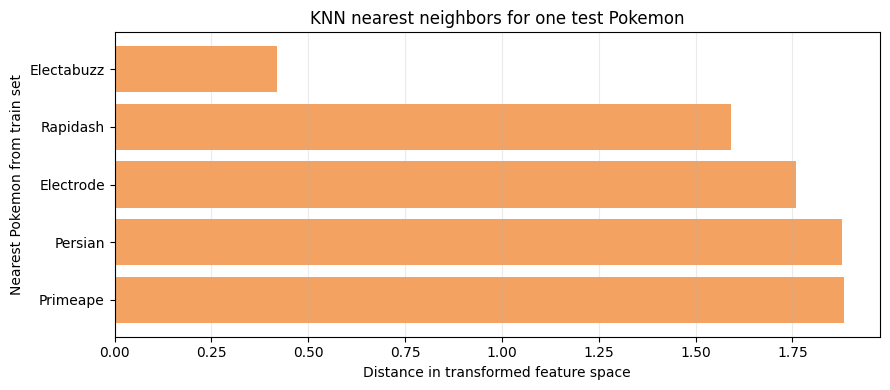

In [12]:
query_row = X_test.sample(1, random_state=RANDOM_STATE)
query_name = str(y_test.loc[query_row.index[0]])

preprocessor = knn_pipeline.named_steps['preprocessor']
knn_model = knn_pipeline.named_steps['model']

X_train_t = preprocessor.transform(X_train)
query_t = preprocessor.transform(query_row)

distances, indices = knn_model.kneighbors(query_t, n_neighbors=5)
neighbor_rows = X_train.iloc[indices[0]].copy()
neighbor_rows['Neighbor Name'] = y_train.iloc[indices[0]].values
neighbor_rows['Distance'] = distances[0]

neighbors_view = (
    neighbor_rows[['Neighbor Name', 'Type 1', 'Type 2', 'Total', 'Speed', 'Legendary', 'Distance']]
    .sort_values('Distance')
    .reset_index(drop=True)
)

print(f'Query Pokemon (ground truth): {query_name}')
display(query_row)
display(neighbors_view)

plt.figure(figsize=(9, 4))
plt.barh(neighbors_view['Neighbor Name'], neighbors_view['Distance'], color='#f4a261')
plt.gca().invert_yaxis()
plt.xlabel('Distance in transformed feature space')
plt.ylabel('Nearest Pokemon from train set')
plt.title('KNN nearest neighbors for one test Pokemon')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Train final model on all data and export artifacts

In [13]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=3, weights="distance")),
    ]
)

final_pipeline.fit(X, y)

joblib_path = MODELS_DIR / "pokemon_knn_pipeline.joblib"
pkl_path = MODELS_DIR / "model.pkl"
metadata_path = MODELS_DIR / "pokemon_metadata.json"

joblib.dump(final_pipeline, joblib_path)
joblib.dump(final_pipeline, pkl_path)

metadata = {
    "target_column": target_col,
    "feature_columns": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "model_type": "KNeighborsClassifier",
    "n_neighbors": 3,
}
metadata_path.write_text(json.dumps(metadata, ensure_ascii=True, indent=2), encoding="utf-8")

print("Saved artifacts:")
print("-", joblib_path)
print("-", pkl_path)
print("-", metadata_path)

Saved artifacts:
- /workspaces/ml_for_production_talk/ml-production-app/models/pokemon_knn_pipeline.joblib
- /workspaces/ml_for_production_talk/ml-production-app/models/model.pkl
- /workspaces/ml_for_production_talk/ml-production-app/models/pokemon_metadata.json


## 9. Inference sanity check

In [14]:
loaded_model = joblib.load(joblib_path)

sample_input = X.sample(1, random_state=RANDOM_STATE)
pred_name = loaded_model.predict(sample_input)[0]
options = top_k_candidates(loaded_model, sample_input, k=3)[0]

print("Input row:")
display(sample_input)
print("Top-1 prediction:", pred_name)
print("Top-3 candidates:", options)

Input row:


,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
100,Ghost,Poison,405,45,50,45,115,55,95,1,False


Top-1 prediction: Haunter
Top-3 candidates: ['Haunter', 'Zubat', 'Hitmonlee']
